# **--- GETAROUND PROJECT (delay analysis)---** #

## **1. Libraries import** ##

In [388]:
import pandas as pd
import numpy as np
import os
import json


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy.stats import chi2_contingency

## **2. Data import and first observations** ##

In [389]:
# Dataset import
raw_df=pd.read_excel("../DATA/raw_data/get_around_delay_analysis.xlsx")
raw_df.head()

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [390]:
# Size of the dataset
raw_df.shape

(21310, 7)

In [391]:
# Statistical information
raw_df.describe(include="all")

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,21310.000000,21310.000000,21310,21310,16346.000000,1841.000000,1841.000000
unique,NaN,NaN,2,2,NaN,NaN,NaN
top,NaN,NaN,mobile,ended,NaN,NaN,NaN
freq,NaN,NaN,17003,18045,NaN,NaN,NaN
mean,549712.880338,350030.603426,NaN,NaN,59.701517,550127.411733,279.288430
std,13863.446964,58206.249765,NaN,NaN,1002.561635,13184.023111,254.594486
min,504806.000000,159250.000000,NaN,NaN,-22433.000000,505628.000000,0.000000
25%,540613.250000,317639.000000,NaN,NaN,-36.000000,540896.000000,60.000000
50%,550350.000000,368717.000000,NaN,NaN,9.000000,550567.000000,180.000000
75%,560468.500000,394928.000000,NaN,NaN,67.000000,560823.000000,540.000000


In [392]:
# Check for duplicates
raw_df.duplicated().any() 

False

In [393]:
# Main information on the dataset
raw_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  object 
 3   state                                       21310 non-null  object 
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB


We can observe the presence of missing values for 3 variables : 
- `delay_at_checkout_in_minutes`,
- `previous_ended_rental_id`,
- `time_delta_with_previous_rental_in_minutes`


In [394]:
# Check for the percentage of missing values per column (in %)
total_nb_rentals=raw_df.shape[0]
round(100*raw_df.isna().sum()/total_nb_rentals,2)

rental_id                                      0.00
car_id                                         0.00
checkin_type                                   0.00
state                                          0.00
delay_at_checkout_in_minutes                  23.29
previous_ended_rental_id                      91.36
time_delta_with_previous_rental_in_minutes    91.36
dtype: float64

We can observe that the proportion of missing values for the variables `previous_ended_rental_id` and `time_delta_with_previous_rental_in_minutes` is very high (91.36%) and identical. This suggests that the missingness may be related either to a lack of available data or to cases where the rental corresponds to the first usage of the car.

Note: We do not have any temporal context here (for example, whether the rentals are recorded per day or over a specific time period), which limits further interpretation.  We are now going to deeper analyze the origin of missing data.

## **3. Missing data analysis (`previous_ended_rental_id` and `time_delta`)** ##

### **3.1. Consistency of missing data** ###

To verify the following hypothesis : the missing values associated with these two variable is linked to a "first rental", we are going to check the following consistency rules:

- No previous rental: both variables should be missing simultaneously.
- Previous rental exists: both variables should be filled.

In other words, missingness should be consistent across the two columns.

In [395]:
# Conditions
both_null = raw_df['previous_ended_rental_id'].isnull() & raw_df['time_delta_with_previous_rental_in_minutes'].isnull()
both_filled = raw_df['previous_ended_rental_id'].notnull() & raw_df['time_delta_with_previous_rental_in_minutes'].notnull()
only_prev_null = raw_df['previous_ended_rental_id'].isnull() & raw_df['time_delta_with_previous_rental_in_minutes'].notnull()
only_delta_null = raw_df['previous_ended_rental_id'].notnull() & raw_df['time_delta_with_previous_rental_in_minutes'].isnull()

# Summary table
coherence_check = pd.DataFrame({
    'Scenario': [
        'Both NULL (consistent)',
        'Both FILLED (consistent)', 
        'Only previous_rental NULL (inconsistent)',
        'Only time_delta NULL (inconsistent)'
    ],
    'Count': [
        both_null.sum(),
        both_filled.sum(),
        only_prev_null.sum(),
        only_delta_null.sum()
    ],
    'Percentage': [
        (both_null.sum() / len(raw_df) * 100).round(2),
        (both_filled.sum() / len(raw_df) * 100).round(2),
        (only_prev_null.sum() / len(raw_df) * 100).round(2),
        (only_delta_null.sum() / len(raw_df) * 100).round(2)
    ]
})

coherence_check


,Scenario,Count,Percentage
0,Both NULL (consistent),19469,91.36
1,Both FILLED (consistent),1841,8.64
2,Only previous_rental NULL (inconsistent),0,0.00
3,Only time_delta NULL (inconsistent),0,0.00


Missing values are consistent across both columns, which indicates that they are associated with the absence of a previous rental during the observed period rather than with data quality issues. As a result, the analysis should focus on cases where a car has multiple consecutive rentals, as these are the situations in which delays can propagate and have an impact. It represents 8,64% of all rentals.

### **3.2. Number of missing data according to the number of rentals** ###

**_3.2.1. Separating cars according to their number of rentals_**

Let's now create 2 groups to devide the cars according to the number of rentals over the period: 
- first group: Cars with one rental only,
- second group: Cars with more than one rental.

In [396]:
# Numbers of cars in the dataset
total_nb_cars=raw_df['car_id'].nunique()
print(f"There is a total of {total_nb_cars} cars in the dataset.")

There is a total of 8143 cars in the dataset.


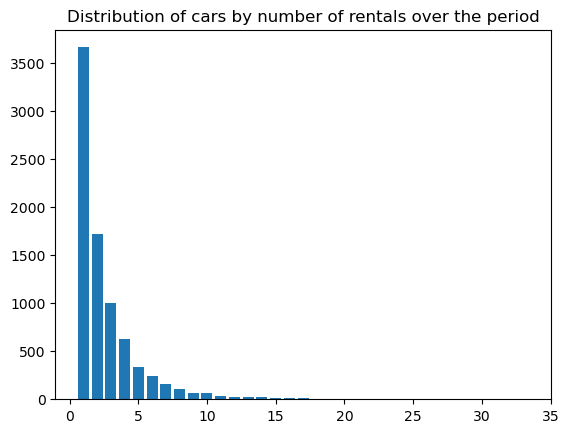

In [397]:
# Count rentals per car
nb_rentals_per_car = raw_df.groupby('car_id').size()
count_per_nb_rental = nb_rentals_per_car.value_counts()

plt.figure()
plt.bar(count_per_nb_rental.index,count_per_nb_rental.values)
plt.title("Distribution of cars by number of rentals over the period")
plt.show()

In [398]:
# Create first group (cars rented only once) :
cars_one_rental_ids = nb_rentals_per_car[nb_rentals_per_car == 1].index
nb_cars_one_rental=cars_one_rental_ids.nunique()
cars_one_rental_df=raw_df[raw_df["car_id"].isin(cars_one_rental_ids)]

print(f"Number of cars with only one rental : {nb_cars_one_rental}.\nThis represents {round((100*cars_one_rental_ids.nunique()/total_nb_cars),2)}% of all cars.")

Number of cars with only one rental : 3659.
This represents 44.93% of all cars.


In [399]:
# Create second group (cars rented more than once) :
cars_several_rentals_ids = nb_rentals_per_car[nb_rentals_per_car > 1].index
nb_cars_several_rentals=cars_several_rentals_ids.nunique()
cars_several_rentals_df=raw_df[raw_df["car_id"].isin(cars_several_rentals_ids)]

print(f"Number of cars with several rentals : {nb_cars_several_rentals}.\nThis represents {round((100*cars_several_rentals_ids.nunique()/total_nb_cars),2)}% of all cars.")

Number of cars with several rentals : 4484.
This represents 55.07% of all cars.


**Out of all cars in the dataset:** 

**- 44,93% have been rented only once over the period of time covered by the dataset,**

**- 55,07% have been rented more than once.**

**_3.2.2. Number of missing values in `previous_ended_rental_id` column according to how many times the car has been rented_**

In [400]:
# Total number of NaN for the variable 'previous_ended_rental_id' in the dataset (all rentals of cars with no previous rentals)
total_nb_nan_prev_rental=raw_df['previous_ended_rental_id'].isna().sum()
total_nb_nan_prev_rental

19469

In [401]:
# Cars with only one rental: all the "previous_ended_rental_id" should be NaN
nb_nan_one_rental=cars_one_rental_df['previous_ended_rental_id'].isna().sum()
nb_nan_one_rental==nb_cars_one_rental

True

All cars that have been rented only once have 'NaN' values for the `previous_ended_rental_id` variable. Now let's check if cars with more than one rental, have exactly one 'NaN' for that variable. Despite the fact that we do not have chronological information, we can suppose that it would correspond to the first rental of the car.

In [402]:
# Cars with more than one rental: they should have exactly one NaN value for the "previous_ended_rental_id" variable corresponding to the first rental of consecutive rentals.
nb_nan_several_rentals = cars_several_rentals_df['previous_ended_rental_id'].isna().sum()

If the total amount of NaN  for the variable `previous_ended_rental_id` corresponds to all rentals without previous rentals. It should be divided into:
- first rentals of cars that are rented only once,
- first rentals of cars that are rented several times.
It means that `nb_nan_one_rental` + `nb_nan_several_rentals` sould be equal to `total_nb_nan_prev_rental`. Let's check that : 

In [403]:
nb_nan_one_rental + nb_nan_several_rentals==total_nb_nan_prev_rental

True

Cars that have been rented more than once have exactly one NaN values in the `previous_ended_rental_id` column. We can thus validate our hypothesis: missing data for the variable `prevous_ended_rental_id` correspond to first rentals of: 
- cars with only one rental in total,
- cars with more than one rental (first rental of a chain of rentals).

To assess the impact of delays on cancellations, we will focus on the 55.07% of cars that are involved in multiple successive rentals.
For these vehicles, we exclude the first rental in each sequence, as it cannot be affected by a prior delay.

The remaining rentals—those exposed to a potential knock-on effect from previous delays—represent 8.64% of all rentals. These rentals are therefore considered as “at risk.”

In [404]:
# Select and save all rows with an "at risk" rental_id: 
risky_rentals_df=raw_df[both_filled] # we select rows with non NaN values for the previous_ended_rental_id
risky_rentals_df.to_excel("../DATA/processed_data/risky_rentals.xlsx")

only_first_rentals_df=raw_df[both_null]
only_first_rentals_df.to_excel("../DATA/processed_data/only_first_rentals.xlsx")

## **4. Missing data analysis (`delay_at_checkout_in_minutes `)** ##

We observed earlier than more than 23% of data are missing for the variable `delta_at_checkout_in_minutes`. Let's determine if it is related to a problem of data collection or if there is a specific meaning to that. This will help us to decide whether to keep or remove these rentals.

### **4.1. Ratios of missing data according to the state of rentals** ###

**4.1.1. Cancellation ratio for all data**

We are first going to see the global ratio of cancellations among all rentals. 

In [405]:
raw_df['state'].value_counts()

state
ended       18045
canceled     3265
Name: count, dtype: int64

Text(0.5, 1.0, 'Ratio of canceled rentals among all rentals')

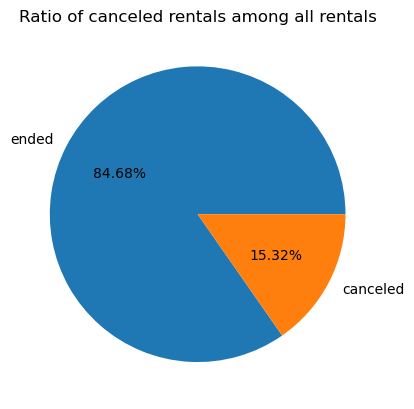

In [406]:
ratio_total_cancelation=plt.pie(raw_df['state'].value_counts(),
        autopct=lambda p: f"{p:.2f}%",
        labels=raw_df['state'].value_counts().index)
plt.title("Ratio of canceled rentals among all rentals")

Out of the 15,32% of missing data, which proportion has missing values for the variable `delay_at_checkout_in_minutes`?

The hypothesis we can verify is the following : rentals that have been canceled have no delay information because there was no checkin nor checkout. For that, we are going to see if there is a difference of missing data ratios according to the state of the rental (canceled vs ended).

**4.1.2. Ratio of missing data (delay) for CANCELED rentals**

In [407]:
total_canceled_rentals_df=raw_df[raw_df['state']=='canceled']
delay_canceled_nan_nb = total_canceled_rentals_df['delay_at_checkout_in_minutes'].isna().sum()
print(f"___ State of the rental: CANCELED ___\n\n{delay_canceled_nan_nb} missing delay values out of {len(total_canceled_rentals_df)}. \nThis represents {100*delay_canceled_nan_nb/len(total_canceled_rentals_df):.2f}% of all canceled rentals. ")

___ State of the rental: CANCELED ___

3264 missing delay values out of 3265. 
This represents 99.97% of all canceled rentals. 


**4.1.3. Ratio of missing data (delay) for ENDED rentals**

In [408]:
total_ended_rentals_df=raw_df[raw_df['state']=='ended']
delay_ended_nan_nb=total_ended_rentals_df['delay_at_checkout_in_minutes'].isna().sum()
print(f"___ State of the rental: ENDED ___\n\n{delay_ended_nan_nb} missing delay values out of {len(total_ended_rentals_df)}. \nThis represents {100*delay_ended_nan_nb/len(total_ended_rentals_df):.2f}% of all canceled rentals.")

___ State of the rental: ENDED ___

1700 missing delay values out of 18045. 
This represents 9.42% of all canceled rentals.


When a rental is canceled, 99.97% of delay information is missing. This strongly supports our hypothesis that missing delay data in canceled rentals is expected and meaningful, as no checkout actually occurred. Consequently, these missing values should not be removed.

For ended rentals, the proportion of missing delay values is much lower (9.42%). This likely reflects data quality issues rather than a structural absence of checkout. At this stage, we choose to retain these observations and apply filtering only when necessary for specific analyses.

Let's evaluate if the position of the rental (first rental or consecutives rentals) has an influence on that variable and its missing values.


### **4.2. Ratio of missing data according to rental position (first or consecutive)** ###

In [409]:
# Identify consecutive vs first rentals
is_consecutive = raw_df['previous_ended_rental_id'].notna()
is_first = raw_df['previous_ended_rental_id'].isna()

print("\nMissing delay rate:")
print(f"- First rentals: {raw_df[is_first]['delay_at_checkout_in_minutes'].isna().sum() / is_first.sum() * 100:.2f}%")
print(f"- Consecutive rentals: {raw_df[is_consecutive]['delay_at_checkout_in_minutes'].isna().sum() / is_consecutive.sum() * 100:.2f}%")


Missing delay rate:
- First rentals: 23.82%
- Consecutive rentals: 17.71%


We can observe a difference. We need to check if it is statistically significant.

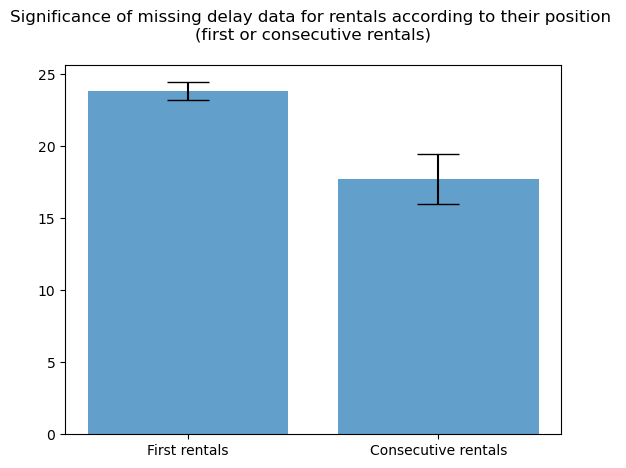

The p-value is: 0.000000


In [410]:
delay_missing = raw_df['delay_at_checkout_in_minutes'].isna()

# First rentals
first_total = is_first.sum()
first_missing = (is_first & delay_missing).sum()
first_rate = first_missing / first_total * 100

# Consecutive rentals
consec_total = is_consecutive.sum()
consec_missing = (is_consecutive & delay_missing).sum()
consec_rate = consec_missing / consec_total * 100

# Error margin calculation for a confidence interval of 95%
def margin_error(rate, n):
    p = rate / 100
    se = np.sqrt(p * (1 - p) / n)
    return 1.96 * se * 100

err1 = margin_error(first_rate, first_total)
err2 = margin_error(consec_rate, consec_total)

# Statistical test
table = [[first_total - first_missing, first_missing],
         [consec_total - consec_missing, consec_missing]]
chi2, p_value, _, _ = chi2_contingency(table)


plt.bar(['First rentals', 'Consecutive rentals'], [first_rate, consec_rate],
        yerr=[err1, err2], capsize=15,
        alpha=0.7)
plt.title("Significance of missing delay data for rentals according to their position \n(first or consecutive rentals)\n")
plt.show()

print(f"The p-value is: {p_value:.6f}")


The rental position has a significant importance on the number of missing delay data. First rentals have 6.11% extra missing information. Maybe after several rentals, the users is more used to the checkout process. 

Missing data for `delay_at_checkout_in_minutes` variable are kept so far because a large part of them carries meaning.

## **5. Understanding delays and cancellations** ##

In order to identify the real impact of delay on cancellations, we need to compare `delay_at_checkout_in_minutes` and `time_delta_with_previous_rental_in_minutes` variables. 

Indeed, if : 
-   `delay_at_checkout_in_minutes` > `time_delta_with_previous_rental_in_minutes` : we are sure to have a conflictual situation,

-   `delay_at_checkout_in_minutes` is close to `time_delta_with_previous_rental_in_minutes` : we have a risky situation,

-   `delay_at_checkout_in_minutes` is very small compare to  `time_delta_with_previous_rental_in_minutes` : we have a low risk of cancellation linked to a delay.

First, let's compare cancellations ratios between first and consecutives rentals. After that, we will focus only on problematic rentals (the risky ones) to analyze delay at checkout and time delta.

### **5.1. Comparison of cancellations ratios between first and consecutive rentals** ###

We studied earlier the total ratio of cancellations. We will now check which proportion of cancellations concerns "risky rentals" (consecutive rentals) compared to "first rentals" to see if there is a difference. Indeed, we need to understand which part of cancellations is linked to delays and not to other reasons.

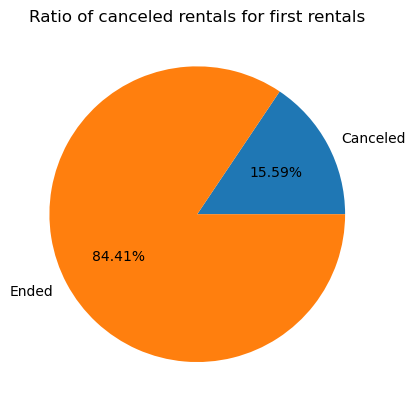

In [411]:
# Ratio of canceled rentals for first rentals:
state_first_rentals = pd.DataFrame({
    'State': ['Canceled','Ended'],
    'Count': [
        (only_first_rentals_df['state']=="canceled").sum(),
        (only_first_rentals_df['state']=="ended").sum()]},
        index=['Canceled','Ended'])
state_first_rentals['Percentage %'] = (state_first_rentals['Count'] / len(only_first_rentals_df) * 100).round(2)

plot=state_first_rentals.plot.pie(
    y='Percentage %',
    autopct=lambda p: f"{p:.2f}%",
    legend=False,
    labels=state_first_rentals.index,
    ylabel='',
    title="Ratio of canceled rentals for first rentals")


Out of all first rentals, 15,59% have been canceled. We need to determine if they are linked to delays or to other reasons. To do so, let's calculate the same ratio for "risky rentals" and compare it to this ratio.

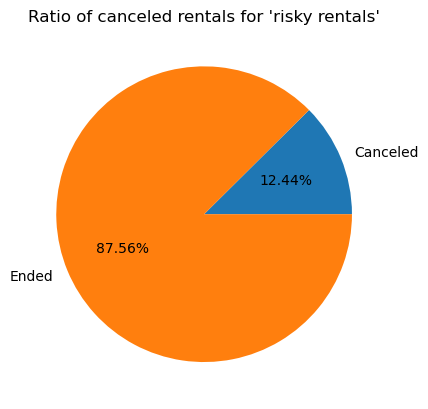

In [412]:
# Ratio of canceled rentals for cars with several rentals.
state_risky_rentals = pd.DataFrame({
    'State': ['Canceled','Ended'],
    'Count': [
        (risky_rentals_df['state']=="canceled").sum(),
        (risky_rentals_df['state']=="ended").sum()]},
        index=['Canceled','Ended'])
state_risky_rentals['Percentage %'] = (state_risky_rentals['Count'] / len(risky_rentals_df) * 100).round(2)

state_risky_rentals 
plot=state_risky_rentals.plot.pie(
    y='Percentage %',
    autopct=lambda p: f"{p:.2f}%",
    legend=False,
    labels=state_risky_rentals.index,
    ylabel='',
    title="Ratio of canceled rentals for 'risky rentals'")


Consecutive rentals show a slightly lower cancellation rate (13.75%) compared to first rentals (15.59%). However, this difference is relatively small, suggesting that rental position alone does not strongly predict cancellations.

### **5.2. `delay_at_checkout_in_minutes` analysis** ###

In [413]:
delays_df =risky_rentals_df['delay_at_checkout_in_minutes'].dropna()
delays_df.describe()

count    1515.000000
mean       27.529373
std       433.981187
min     -2676.000000
25%       -47.000000
50%         4.000000
75%        54.000000
max      9787.000000
Name: delay_at_checkout_in_minutes, dtype: float64

In [414]:
# Categorize delays
print(f"Early checkout (delay < 0): {(delays_df < 0).sum()} ({100*round((delays_df < 0).sum()/len(delays_df),2)} %)")
print(f"On time (delay = 0): {(delays_df == 0).sum()} ({100*round((delays_df == 0).sum()/len(delays_df),2)} %)")
print(f"Late checkout (delay > 0): {(delays_df > 0).sum()} ({100*round((delays_df > 0).sum()/len(delays_df),2)} %)")

Early checkout (delay < 0): 699 (46.0 %)
On time (delay = 0): 14 (1.0 %)
Late checkout (delay > 0): 802 (53.0 %)


In [415]:
positive_delays_df=delays_df[delays_df > 0]
positive_delays_df.describe()

count     802.00000
mean      159.57980
std       524.01691
min         1.00000
25%        20.25000
50%        50.00000
75%       107.00000
max      9787.00000
Name: delay_at_checkout_in_minutes, dtype: float64

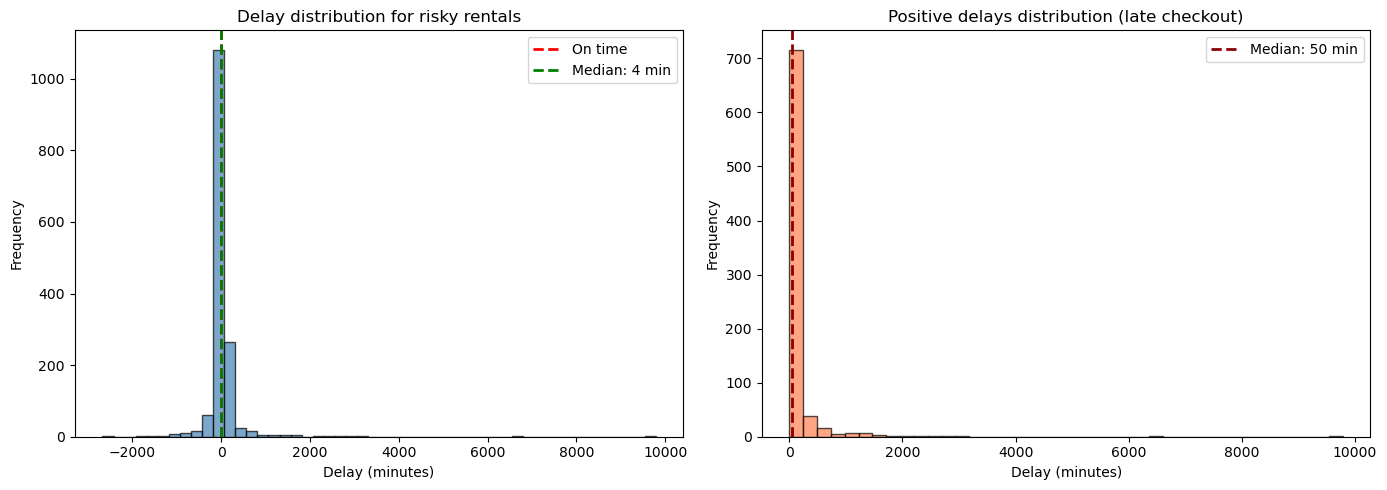

In [416]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(delays_df, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='On time')
axes[0].axvline(delays_df.median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {delays_df.median():.0f} min')
axes[0].set_xlabel('Delay (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Delay distribution for risky rentals')
axes[0].legend()

# Focus on late checkouts only
late_delays = delays_df[delays_df > 0]
axes[1].hist(late_delays, bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(late_delays.median(), color='darkred', linestyle='--', linewidth=2,
                label=f'Median: {late_delays.median():.0f} min')
axes[1].set_xlabel('Delay (minutes)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Positive delays distribution (late checkout)')
axes[1].legend()


plt.tight_layout()
plt.show()

We can see that out af all risky rentals, 53% have late checkouts. Among the late checkouts, the typical delay is 50 mins (the median).

### **5.3. `time_delta_with_previous_rental_in_minutes` analysis** ###

**_5.3.1 "Time delta" general analysis_**

In [417]:
time_deltas = risky_rentals_df['time_delta_with_previous_rental_in_minutes'].dropna()
time_deltas.describe()

count    1841.000000
mean      279.288430
std       254.594486
min         0.000000
25%        60.000000
50%       180.000000
75%       540.000000
max       720.000000
Name: time_delta_with_previous_rental_in_minutes, dtype: float64

In [418]:
print(f"Mean time delta: {time_deltas.mean()/60:.1f} hours")
print(f"Median time delta: {time_deltas.median()/60:.1f} hours")

Mean time delta: 4.7 hours
Median time delta: 3.0 hours


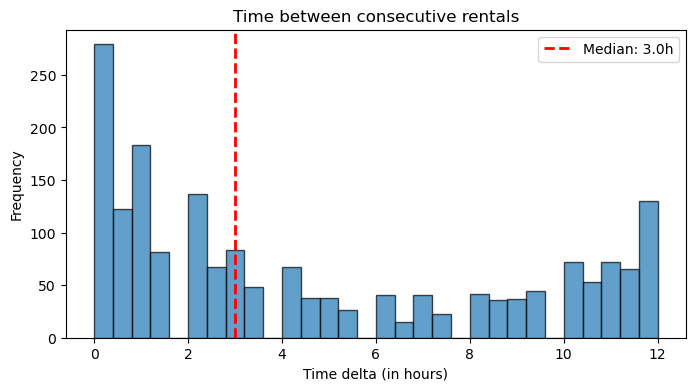

In [419]:
plt.figure(figsize=(8, 4))
plt.hist(time_deltas/60, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(time_deltas.median()/60, color='red', linestyle='--', linewidth=2,
            label=f'Median: {time_deltas.median()/60:.1f}h')
plt.xlabel('Time delta (in hours)')
plt.ylabel('Frequency')
plt.title('Time between consecutive rentals')
plt.legend()
plt.show()

**_5.3.2 "Time delta" analysis according to the state of rentals (canceled or ended)_**

We first divide the risky rentals into two groups : 
- Canceled rentals
- Ended rentals

In [420]:
canceled_risky_rentals_df=risky_rentals_df[risky_rentals_df['state']=='canceled']
ended_risky_rentals_df=risky_rentals_df[risky_rentals_df['state']=='ended']
print( f"Out of all risky rentals ({len(risky_rentals_df)} rentals), {len(canceled_risky_rentals_df)} have been canceled.")

Out of all risky rentals (1841 rentals), 229 have been canceled.


In [421]:
canceled_risky_rentals_df["time_delta_with_previous_rental_in_minutes"].describe()

count    229.000000
mean     294.890830
std      250.591601
min        0.000000
25%       60.000000
50%      210.000000
75%      570.000000
max      720.000000
Name: time_delta_with_previous_rental_in_minutes, dtype: float64

In [422]:
print(f"Canceled risky rentals:")
print(f"- Median time delta: {canceled_risky_rentals_df['time_delta_with_previous_rental_in_minutes'].median():.0f} min ({canceled_risky_rentals_df['time_delta_with_previous_rental_in_minutes'].median()/60:.1f}h)")
print(f"- Mean time delta: {canceled_risky_rentals_df['time_delta_with_previous_rental_in_minutes'].mean():.0f} min ({canceled_risky_rentals_df['time_delta_with_previous_rental_in_minutes'].mean()/60:.1f}h)")

Canceled risky rentals:
- Median time delta: 210 min (3.5h)
- Mean time delta: 295 min (4.9h)


In [423]:
ended_risky_rentals_df["time_delta_with_previous_rental_in_minutes"].describe()

count    1612.000000
mean      277.071960
std       255.157331
min         0.000000
25%        60.000000
50%       180.000000
75%       540.000000
max       720.000000
Name: time_delta_with_previous_rental_in_minutes, dtype: float64

In [424]:
print(f"Ended risky rentals:")
print(f"- Median time delta: {ended_risky_rentals_df['time_delta_with_previous_rental_in_minutes'].median():.0f} min ({ended_risky_rentals_df['time_delta_with_previous_rental_in_minutes'].median()/60:.1f}h)")
print(f"- Mean time delta: {ended_risky_rentals_df['time_delta_with_previous_rental_in_minutes'].mean():.0f} min ({ended_risky_rentals_df['time_delta_with_previous_rental_in_minutes'].mean()/60:.1f}h)")

Ended risky rentals:
- Median time delta: 180 min (3.0h)
- Mean time delta: 277 min (4.6h)


Althought time deltas ranges are the same according to the state of the rental (from 0 min to 720 min (=12h)), we see that ended rentals have a lower median and mean than canceled rentals.

### **5.4. Problematic situations** ###

We now need to identify situations where delays create actual conflicts with the next rental. 

A problematic situation occurs when the delay from the previous checkout reduces or eliminates the buffer time before the next rental. We will categorize rentals based on their risk level:

- **Critical cases**: `delay_at_checkout_in_minutes` > `time_delta_with_previous_rental_in_minutes` → The next driver will definitely wait or the rental will be canceled
- **High risk cases**: positive delay + short time delta (< 2 hours) → High probability of friction (we saw earlier that the median for delays was 50 min).
- **Medium risk cases**: positive delay + moderate time delta (2-4 hours) → Some friction possible
- **Low risk cases**: no delay or early checkout, or large time delta → No significant impact expected

In [ ]:
# # Filter to rentals with both delay and time_delta information (no missing values)
# risky_rentals_no_nan_df = risky_rentals_df[
#     risky_rentals_df['delay_at_checkout_in_minutes'].notna() & 
#     risky_rentals_df['time_delta_with_previous_rental_in_minutes'].notna()
# ].copy()

# print(f"Risky rentals with complete data (delay + time_delta): {len(risky_rentals_no_nan_df)}")
# print(f"This represents {100*len(risky_rentals_no_nan_df)/len(risky_rentals_df):.2f}% of all risky rentals")

Risky rentals with complete data (delay + time_delta): 1515
This represents 82.29% of all risky rentals


**_5.4.1. Identification of "risk levels" for all consecutives rentals_**

We are now going to divide our dataset according to the "risk level" each rental belongs to. 

In [491]:
df = risky_rentals_df.copy()

df['is_late'] = df['delay_at_checkout_in_minutes'] > 0
df['is_critical'] = (
    df['delay_at_checkout_in_minutes'] >
    df['time_delta_with_previous_rental_in_minutes']
)

df['risk_level'] = 'Low (on time or large time delta >= 4h)'

# Critical
df.loc[df['is_critical'], 'risk_level'] = 'Critical (delay > time delta)'

# High risk (late + < 2h time delta, excluding critical)
df.loc[
    (~df['is_critical']) &
    (df['is_late']) &
    (df['time_delta_with_previous_rental_in_minutes'] < 120),
    'risk_level'
] = 'High (late + time delta < 2h)'

# Medium risk (late + 2–4h time delta)
df.loc[
    (~df['is_critical']) &
    (df['is_late']) &
    (df['time_delta_with_previous_rental_in_minutes'].between(120, 240)),
    'risk_level'
] = 'Medium (late + time delta 2–4h)'


In [505]:
# Number of rentals and % for all risk levels
risk_distribution_df = (
    df['risk_level']
    .value_counts()
    .reset_index()
    .rename(columns={
        'index': '',
        'risk_level': 'Risk level',
        'count':'Number of rentals'
    })
)

risk_distribution_df['Percentage of all rentals (%)'] = (
    risk_distribution_df['Number of rentals'] / len(df) * 100
).round(2)

risk_distribution_df

,Risk level,Number of rentals,Percentage of all rentals (%)
0,Low (on time or large time delta >= 4h),1334,72.46
1,Critical (delay > time delta),270,14.67
2,Medium (late + time delta 2–4h),151,8.20
3,High (late + time delta < 2h),86,4.67


Critical cases represent situations where implementing a minimum threshold would have the most immediate impact, as these are guaranteed conflicts where the next customer had to wait or cancel.

**_5.4.2. Ratio of cancellations per risk level_**

Is there a difference of cancellation rate according to the risk level (for example a higher cancellation rate for critical or high risk levels)? We can check that : 

In [506]:
# Number of cancellations per risk level categories.
risk_names_list = df['risk_level'].unique().tolist()

nb_cancellations = []
percentage_cancellations = []

for risk in risk_names_list:
    df_risk = df[df['risk_level'] == risk]
    
    nb_cancel = len(df_risk[df_risk['state'] == 'canceled'])
    nb_total = len(df_risk)
    
    nb_cancellations.append(nb_cancel)
    percentage_cancellations.append(100 * nb_cancel / nb_total if nb_total > 0 else 0)

pd.DataFrame({
    "Risk level": risk_names_list,
    "Nb_cancellations": nb_cancellations,
    "Percentage of canceled rentals (%)": [round(p, 2) for p in percentage_cancellations]
})

,Risk level,Nb_cancellations,Percentage of canceled rentals (%)
0,Low (on time or large time delta >= 4h),229,17.17
1,Critical (delay > time delta),0,0.00
2,Medium (late + time delta 2–4h),0,0.00
3,High (late + time delta < 2h),0,0.00


No cancellations have been detected in this dataset for critical, high and medium risk rentals. All of them are observed for "low" risk rentals. We can suggest that they have more time to cancel their rentals or that if the custumer is under a certain level of time he/she is not allowed to cancel anymore. (This should be checked with the cancellation policy).

**_5.4.2. Visualization: delays vs time delta_**

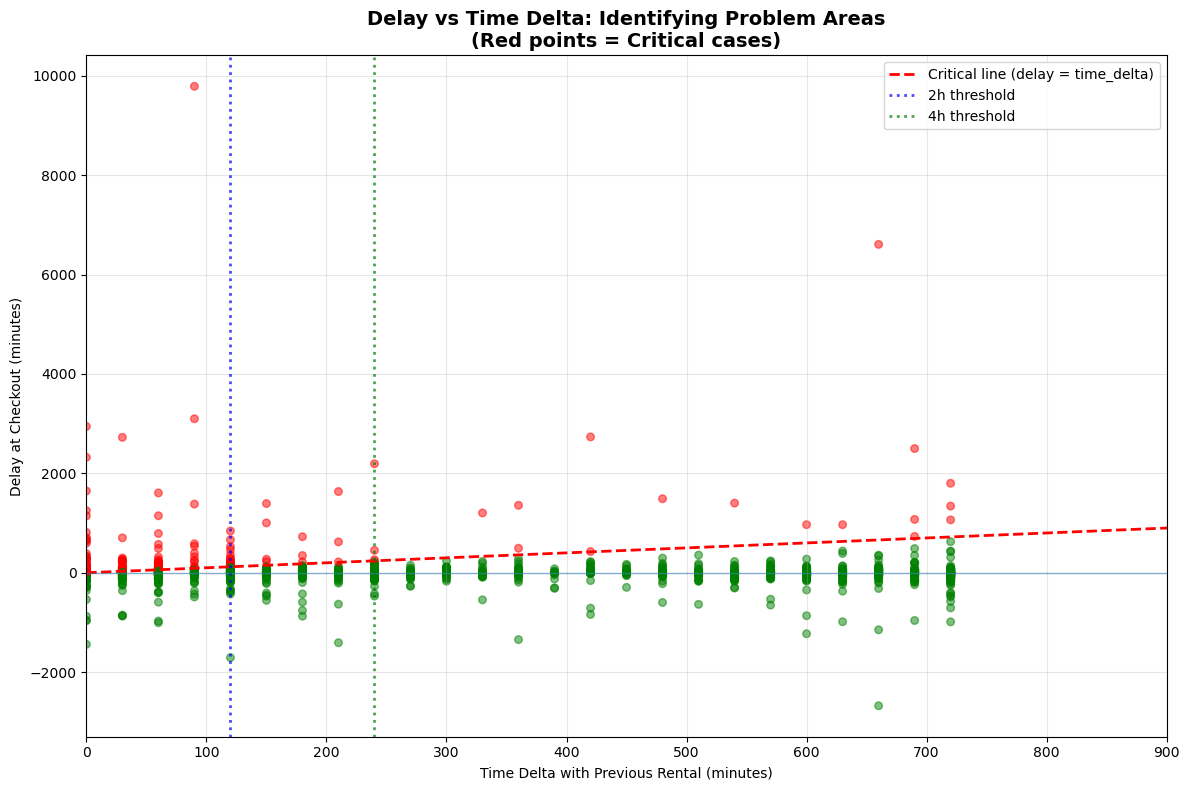


Points above the red line represent conflicts that are certain.
These cases would benefit most from implementing a minimum threshold.


In [ ]:
plt.figure(figsize=(12, 8))

color_map = {
    'Critical (delay > time delta)': 'red',
    'High (late + buffer < 2h)': 'yellow',
    'Medium (late + buffer 2–4h)': 'grey',
    'Low (on time or large buffer >= 4h)': 'green'
}

colors = df['risk_level'].apply(
    lambda x: color_map[x] if x in color_map else 'green'
)

# Scatter plot
plt.scatter(
    df['time_delta_with_previous_rental_in_minutes'],
    df['delay_at_checkout_in_minutes'],
    c=colors,
    alpha=0.5,
    s=30
)
plt.xlim(0, 900) 

# Add critical line (where delay = time_delta)
max_val = max(
    df['time_delta_with_previous_rental_in_minutes'].max(),
    df['delay_at_checkout_in_minutes'].max()
)
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Critical line (delay = time_delta)')

# Add threshold lines for reference
plt.axvline(x=120, color='blue', linestyle=':', linewidth=2, alpha=0.7, label='2h threshold')
plt.axvline(x=240, color='green', linestyle=':', linewidth=2, alpha=0.7, label='4h threshold')
plt.axhline(y=0, linestyle='-', linewidth=1, alpha=0.5)

plt.xlabel('Time Delta with Previous Rental (minutes)')
plt.ylabel('Delay at Checkout (minutes)')
plt.title('Delay vs Time Delta: Identifying Problem Areas\n(Red points = Critical cases)', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPoints above the red line represent conflicts that are certain.")
print(f"These cases would benefit most from implementing a minimum threshold.")

The scatter plot clearly shows that most critical cases (points above the red diagonal line) occur when the time delta is short. This visualization confirms that a minimum threshold between consecutive rentals would prevent the majority of conflict situations.

### **5.5. Impact of checking type** ###

We now examine whether the checkin type (mobile vs connect) influences delay patterns and risk levels. This analysis will help determine if the minimum threshold policy should apply differently to different checkin types.

In [512]:
# Distribution of checkin types in risky rentals
print("Checkin Type Distribution in Risky Rentals:")
print(risky_rentals_df['checkin_type'].value_counts())
print(f"\nPercentages:")
print(round(100*risky_rentals_df['checkin_type'].value_counts(normalize=True),2))

Checkin Type Distribution in Risky Rentals:
checkin_type
mobile     1028
connect     813
Name: count, dtype: int64

Percentages:
checkin_type
mobile     55.84
connect    44.16
Name: proportion, dtype: float64


There are more rentals with a mobile checkout than a connect one.

In [513]:
# Compare delay patterns by checkin type
checkin_types = risky_rentals_df['checkin_type'].unique()

print("\nDelay Statistics by Checkin Type:")
print("=" * 60)

for checkin in checkin_types:
    subset = risky_rentals_df[risky_rentals_df['checkin_type'] == checkin]
    delays_subset = subset['delay_at_checkout_in_minutes']
    
    late_count = (delays_subset > 0).sum()
    late_rate = 100 * late_count / len(delays_subset)
    
    print(f"\n{checkin.upper()}:")
    print(f"  Total rentals: {len(subset)}")
    print(f"  Late checkouts: {late_count} ({late_rate:.1f}%)")
    print(f"  Mean delay: {delays_subset.mean():.1f} min")
    print(f"  Median delay: {delays_subset.median():.1f} min")
    print(f"  Std deviation: {delays_subset.std():.1f} min")


Delay Statistics by Checkin Type:

CONNECT:
  Total rentals: 813
  Late checkouts: 276 (33.9%)
  Mean delay: -36.3 min
  Median delay: -12.0 min
  Std deviation: 177.5 min

MOBILE:
  Total rentals: 1028
  Late checkouts: 526 (51.2%)
  Mean delay: 77.0 min
  Median delay: 13.5 min
  Std deviation: 551.6 min


In [ ]:
# Checkin type vs risk level

pd.DataFrame({
    "Risk level": risk_names_list,
    "Connect (count)" : [len(df[(df['risk_level'] == risk) & (df['checkin_type']=='connect')]) for risk in risk_names_list],
    "Connect (%)" : [round(100*len(df[(df['risk_level'] == risk) & (df['checkin_type']=='connect')])/len(df[df["checkin_type"]=='connect']),2) for risk in risk_names_list],
    "Mobile (count)" :[len(df[(df['risk_level'] == risk) & (df['checkin_type']=='mobile')]) for risk in risk_names_list],
    "Mobile (%)" : [round(100*len(df[(df['risk_level'] == risk) & (df['checkin_type']=='mobile')])/len(df[df["checkin_type"]=='mobile']),2) for risk in risk_names_list],
})

,Risk level,Connect (count),Connect (%),Mobile (count),Mobile (%)
0,Low (on time or large time delta >= 4h),644,79.21,690,67.12
1,Critical (delay > time delta),80,9.84,190,18.48
2,Medium (late + time delta 2–4h),50,6.15,101,9.82
3,High (late + time delta < 2h),39,4.80,47,4.57


The proportion of Critical and Medium risks is higher for mobile checkin than for connect checkin.